First 10 Records:
    invoice_id branch       city customer_type gender_customer  \
0  750-67-8428      A     Yangon        Member          Female   
1  226-31-3081      C  Naypyitaw        Normal          Female   
2  631-41-3108      A     Yangon        Normal            Male   
3  123-19-1176      A     Yangon        Member            Male   
4  373-73-7910      A     Yangon        Normal            Male   
5  699-14-3026      C  Naypyitaw        Normal            Male   
6  355-53-5943      A     Yangon        Member          Female   
7  315-22-5665      C  Naypyitaw        Normal          Female   
8  665-32-9167      A     Yangon        Member          Female   
9  692-92-5582      B   Mandalay        Member          Female   

             product_line  unit_cost  quantity  5pct_markup   revenue  \
0       Health and beauty      74.69         7      26.1415  548.9715   
1  Electronic accessories      15.28         5       3.8200   80.2200   
2      Home and lifestyle      46.33

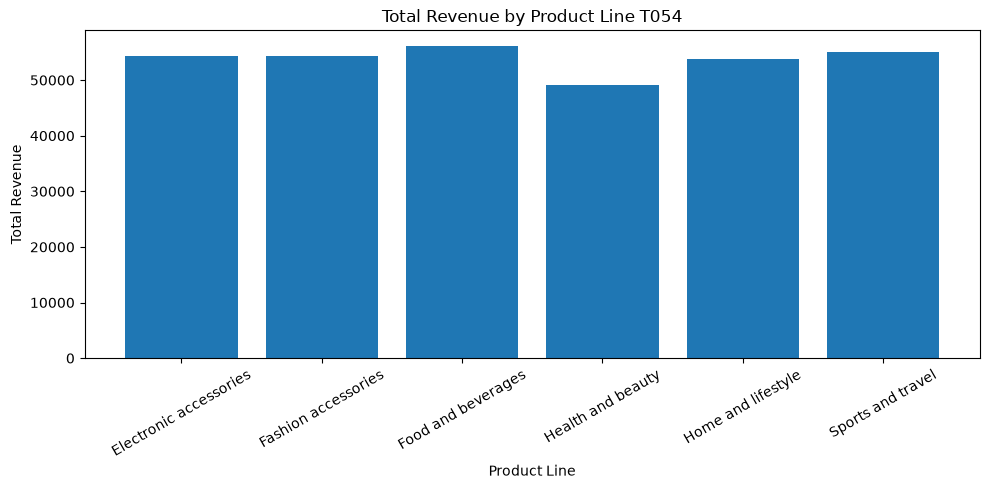

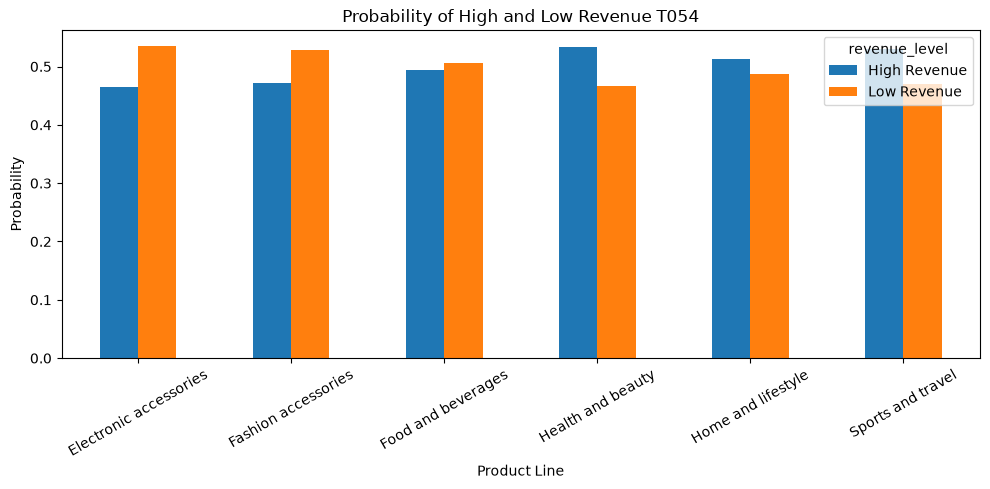


========== FINAL RESULT ==========
Product Line with Highest Probability of High Revenue:
Health and beauty
Probability: 0.533

Priti Yadav T054


In [5]:
import pandas as pd
import matplotlib.pyplot as plt
# 1. Load dataset
df = pd.read_csv("supermarket_sales.csv")
print("First 10 Records:")
print(df.head(10))
# 2. Dataset information
print("\nNumber of Records:", df.shape[0])
print("Number of Columns:", df.shape[1])
print("\nColumn Names:")
print(df.columns.tolist())
print("\nData Types:")
print(df.dtypes)
# 3. Unique product lines
print("\nUnique Product Lines:")
print(df["product_line"].unique())
# 4. Total revenue by product line
total_revenue = df.groupby("product_line")["revenue"].sum()
print("\nTotal Revenue by Product Line:")
print(total_revenue)
# 5. Average revenue by product line
average_revenue = df.groupby("product_line")["revenue"].mean()
print("\nAverage Revenue by Product Line:")
print(average_revenue)
# 6. Total quantity by product line
total_quantity = df.groupby("product_line")["quantity"].sum()
print("\nTotal Quantity Sold by Product Line:")
print(total_quantity)
# 7. Median revenue
median_revenue = df["revenue"].median()
print("\nMedian Revenue:")
print(median_revenue)
# 8 & 9. Classify transactions
df["revenue_level"] = df["revenue"].apply(
    lambda x: "High Revenue"
    if x >= median_revenue
    else "Low Revenue"
)
print("\nRevenue Classification:")
print(
    df[["product_line", "revenue", "revenue_level"]].head(10)
)
# 10. Number of High and Low Revenue transactions
revenue_count = pd.crosstab(
    df["product_line"],
    df["revenue_level"]
)
print("\nNumber of High and Low Revenue Transactions:")
print(revenue_count)
# 11. Probability of High and Low Revenue
probability = pd.crosstab(
    df["product_line"],
    df["revenue_level"],
    normalize="index"
)
print("\nProbability of High and Low Revenue:")
print(probability)
# 12. Verify probabilities add up to 1
probability_sum = probability.sum(axis=1)
print("\nProbability Sum for Each Product Line:")
print(probability_sum)
# 13. Average revenue for High and Low Revenue
average_payoff = df.groupby(
    ["product_line", "revenue_level"]
)["revenue"].mean()
print("\nAverage Revenue / Payoff:")
print(average_payoff)
# 14. Create Decision Tree DataFrame
decision_data = []
for product in df["product_line"].unique():
    product_data = df[
        df["product_line"] == product
    ]
    for outcome in ["High Revenue", "Low Revenue"]:
        outcome_data = product_data[
            product_data["revenue_level"] == outcome
        ]
        if len(outcome_data) > 0:
            prob = len(outcome_data) / len(product_data)
            payoff = outcome_data["revenue"].mean()
        else:
            prob = 0
            payoff = 0
        decision_data.append([
            product,
            outcome,
            prob,
            payoff
        ])
decision_df = pd.DataFrame(
    decision_data,
    columns=[
        "Product Line",
        "Revenue Level",
        "Probability",
        "Payoff"
    ]
)
print("\nDecision Tree DataFrame:")
print(decision_df)
# 15. Decision alternatives and uncertain outcomes
print("\nDecision Alternatives:")
print(df["product_line"].unique())
print("\nUncertain Outcomes:")
print(df["revenue_level"].unique())
# 16 & 17. Construct and display decision tree
print("\n========== DECISION TREE ==========")
for product in df["product_line"].unique():
    print("\nDecision Alternative:", product)
    data = decision_df[
        decision_df["Product Line"] == product
    ]
    for _, row in data.iterrows():
        print(
            "   |---->",
            row["Revenue Level"],
            "| Probability =",
            round(row["Probability"], 3),
            "| Payoff =",
            round(row["Payoff"], 2)
        )
# 18. Visualization - Total Revenue
plt.figure(figsize=(10, 5))
plt.bar(
    total_revenue.index,
    total_revenue.values
)
plt.title("Total Revenue by Product Line T054")
plt.xlabel("Product Line")
plt.ylabel("Total Revenue")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
# 19. Visualization - Probability
probability.plot(
    kind="bar",
    figsize=(10, 5)
)
plt.title("Probability of High and Low Revenue T054")
plt.xlabel("Product Line")
plt.ylabel("Probability")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
# 20. Product line with highest probability of High Revenue
highest_high_probability = probability[
    "High Revenue"
].idxmax()
highest_probability = probability[
    "High Revenue"
].max()
print("\n========== FINAL RESULT ==========")
print(
    "Product Line with Highest Probability of High Revenue:"
)
print(highest_high_probability)
print(
    "Probability:",
    round(highest_probability, 3)
)
print("\nPriti Yadav T054")

21. Expected Value is used to compare different
product lines by considering both probability and payoff.
The product line with the highest Expected Value is
selected as the best business decision.

22. Expected Value Formula:
EV = (Probability of High Revenue × High Revenue Payoff)
     + (Probability of Low Revenue × Low Revenue Payoff)

23. Expected Value of One Product Line:
Health and beauty
Expected Value = 323.64

24. Expected Value of Every Product Line:
             Product Line  Expected Value
0       Health and beauty      323.643020
1  Electronic accessories      319.632538
2      Home and lifestyle      336.636956
3       Sports and travel      332.065220
4      Food and beverages      322.671517
5     Fashion accessories      305.089298

25. Expected Value DataFrame:
             Product Line  High Revenue Probability  High Revenue Payoff  \
0       Health and beauty                  0.532895           497.221407   
1  Electronic accessories                  0.464706     

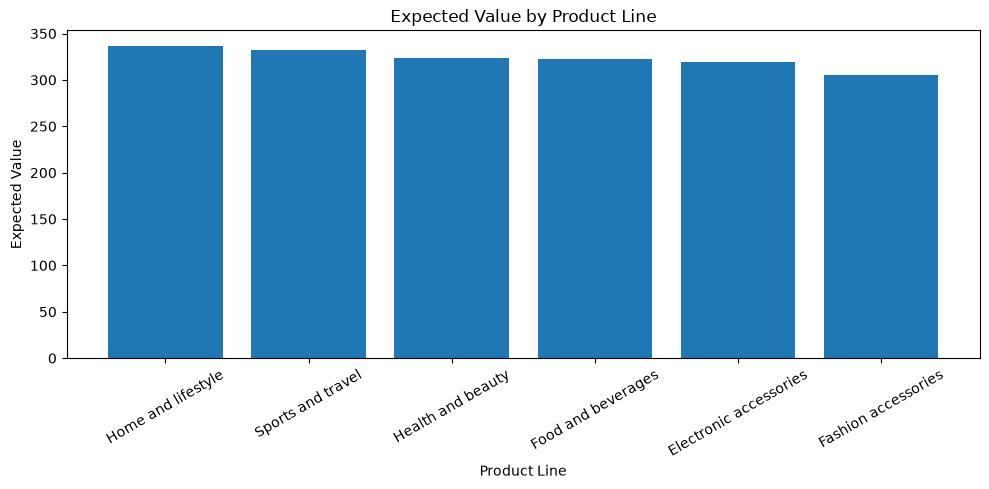


31. Highest Probability of High Revenue:
Health and beauty
Probability: 0.533

Highest Expected Value:
Home and lifestyle

32. Comparison:
No, they are different product lines.

33. Changing Probability:
Product Line: Health and beauty
Old High Revenue Probability: 0.533
New High Revenue Probability: 0.633
New Expected Value: 360.8

34. Changing Payoff:
Product Line: Health and beauty
Old High Revenue Payoff: 497.22
New High Revenue Payoff: 546.94
New Expected Value: 350.14

35. Automatic Decision:
Selected Product Line: Home and lifestyle
Highest Expected Value: 336.64

========== 36. FINAL DECISION TREE ==========

 Health and beauty
   |---- High Revenue
   |     Probability = 0.533 Payoff = 497.22
   |---- Low Revenue
         Probability = 0.467 Payoff = 125.62
   Expected Value = 323.64

 Electronic accessories
   |---- High Revenue
   |     Probability = 0.465 Payoff = 537.01
   |---- Low Revenue
         Probability = 0.535 Payoff = 130.92
   Expected Value = 319.63

 Home and

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
# Load dataset
df = pd.read_csv("supermarket_sales.csv")
# Find median revenue
median_revenue = df["revenue"].median()
# Classify revenue
df["revenue_level"] = df["revenue"].apply(
    lambda x: "High Revenue"
    if x >= median_revenue
    else "Low Revenue")
# 21. Explain Expected Value
print("21. Expected Value is used to compare different")
print("product lines by considering both probability and payoff.")
print("The product line with the highest Expected Value is")
print("selected as the best business decision.")
# 22. Expected Value Formula
print("\n22. Expected Value Formula:")
print("EV = (Probability of High Revenue × High Revenue Payoff)")
print("     + (Probability of Low Revenue × Low Revenue Payoff)")
# Calculate probabilities and payoffs
decision_data = []
for product in df["product_line"].unique():
    product_data = df[
        df["product_line"] == product]
    high_data = product_data[
        product_data["revenue_level"] == "High Revenue" ]
    low_data = product_data[
        product_data["revenue_level"] == "Low Revenue"]
    high_probability = len(high_data) / len(product_data)
    low_probability = len(low_data) / len(product_data)
    high_payoff = high_data["revenue"].mean()
    low_payoff = low_data["revenue"].mean()
    decision_data.append([
        product,
        high_probability,
        high_payoff,
        low_probability,
        low_payoff])
# Create DataFrame
ev_df = pd.DataFrame(
    decision_data,
    columns=[
        "Product Line",
        "High Revenue Probability",
        "High Revenue Payoff",
        "Low Revenue Probability",
        "Low Revenue Payoff"])
# 23. Calculate EV of one product line
first_product = ev_df.iloc[0]
high_p = first_product["High Revenue Probability"]
high_payoff = first_product["High Revenue Payoff"]
low_p = first_product["Low Revenue Probability"]
low_payoff = first_product["Low Revenue Payoff"]
first_ev = (
    high_p * high_payoff
    +
    low_p * low_payoff)
print("\n23. Expected Value of One Product Line:")
print(first_product["Product Line"])
print("Expected Value =", round(first_ev, 2))
# 24. Calculate EV for every product line
ev_df["Expected Value"] = (
    ev_df["High Revenue Probability"]
    * ev_df["High Revenue Payoff"]
    +
    ev_df["Low Revenue Probability"]
    * ev_df["Low Revenue Payoff"])
print("\n24. Expected Value of Every Product Line:")
print(
    ev_df[
        ["Product Line", "Expected Value"]])
# 25. Complete Expected Value DataFrame
print("\n25. Expected Value DataFrame:")
print(ev_df)
# 26. Compare Expected Values
print("\n26. Comparison of Expected Values:")
comparison = ev_df[
    ["Product Line", "Expected Value"]
].sort_values(
    "Expected Value",
    ascending=False)
print(comparison)
# 27. Highest Expected Value
highest_product = ev_df.loc[
    ev_df["Expected Value"].idxmax(),
    "Product Line"]
highest_ev = ev_df["Expected Value"].max()
print("\n27. Product Line with Highest Expected Value:")
print(highest_product)
print("Expected Value:", round(highest_ev, 2))
# 28. Lowest Expected Value
lowest_product = ev_df.loc[
    ev_df["Expected Value"].idxmin(),
    "Product Line"]
lowest_ev = ev_df["Expected Value"].min()
print("\n28. Product Line with Lowest Expected Value:")
print(lowest_product)
print("Expected Value:", round(lowest_ev, 2))
# 29. Rank Product Lines
ranking = ev_df.sort_values(
    "Expected Value",
    ascending=False
)
print("\n29. Ranking from Highest to Lowest:")
print(
    ranking[
        ["Product Line", "Expected Value"]
    ])
# 30. Bar Chart of Expected Values
plt.figure(figsize=(10, 5))
plt.bar(
    ranking["Product Line"],
    ranking["Expected Value"])
plt.title("Expected Value by Product Line")
plt.xlabel("Product Line")
plt.ylabel("Expected Value")
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()
# 31. Highest High Revenue Probability
highest_probability_product = ev_df.loc[
    ev_df["High Revenue Probability"].idxmax(),
    "Product Line"]
highest_probability = ev_df[
    "High Revenue Probability"
].max()
print("\n31. Highest Probability of High Revenue:")
print(highest_probability_product)
print(
    "Probability:",
    round(highest_probability, 3))
print("\nHighest Expected Value:")
print(highest_product)
# 32. Compare Both
print("\n32. Comparison:")
if highest_probability_product == highest_product:
    print(
        "Yes, both are the same product line.")
else:
    print(
        "No, they are different product lines." )
# 33. Change Probability and Recalculate EV
print("\n33. Changing Probability:")
test_product = ev_df.iloc[0]
old_high_probability = test_product[
    "High Revenue Probability"
]
new_high_probability = old_high_probability + 0.10
if new_high_probability > 1:
    new_high_probability = 1
new_low_probability = 1 - new_high_probability
changed_probability_ev = (
    new_high_probability
    * test_product["High Revenue Payoff"]
    +
    new_low_probability
    * test_product["Low Revenue Payoff"])
print(
    "Product Line:",
    test_product["Product Line"])
print(
    "Old High Revenue Probability:",
    round(old_high_probability, 3))
print(
    "New High Revenue Probability:",
    round(new_high_probability, 3))
print(
    "New Expected Value:",
    round(changed_probability_ev, 2))
# 34. Change Payoff and Recalculate EV
print("\n34. Changing Payoff:")
old_payoff = test_product[
    "High Revenue Payoff"]
new_payoff = old_payoff * 1.10
changed_payoff_ev = (
    test_product["High Revenue Probability"]
    * new_payoff
    +
    test_product["Low Revenue Probability"]
    * test_product["Low Revenue Payoff"])
print(
    "Product Line:",
    test_product["Product Line"])
print(
    "Old High Revenue Payoff:",
    round(old_payoff, 2)
)
print(
    "New High Revenue Payoff:",
    round(new_payoff, 2)
)
print(
    "New Expected Value:",
    round(changed_payoff_ev, 2))
# 35. Automatically Select Best Product Line
best_product = ev_df.loc[
    ev_df["Expected Value"].idxmax(),
    "Product Line"]
best_value = ev_df["Expected Value"].max()
print("\n35. Automatic Decision:")
print(
    "Selected Product Line:",
    best_product
)
print(
    "Highest Expected Value:",
    round(best_value, 2))
# 36. Final Decision Tree with EV
print("\n========== 36. FINAL DECISION TREE ==========")
for _, row in ev_df.iterrows():
    print("\n", row["Product Line"])
    print(
        "   |---- High Revenue")
    print(
        "   |     Probability =",
        round(row["High Revenue Probability"], 3),
        "Payoff =",
        round(row["High Revenue Payoff"], 2))
    print(
        "   |---- Low Revenue" )
    print(
        "         Probability =",
        round(row["Low Revenue Probability"], 3),
        "Payoff =",
        round(row["Low Revenue Payoff"], 2) )
    print(
        "   Expected Value =",
        round(row["Expected Value"], 2))
# 37. Business Recommendation
print("\n========== 37. BUSINESS RECOMMENDATION ==========")
print(
    "The business should select the",
    best_product,
    "product line.")
print(
    "It has the highest Expected Value of",
    round(best_value, 2))
print(
    "Therefore, it provides the best expected",
    "business outcome among the available alternatives.")
print("\nPriti Yadav T054")